In [1]:
# Cell 1: Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Cell 2: Load preprocessed data
with open('../data/preprocessed_data.pkl', 'rb') as f:
    data_dict = pickle.load(f)

X_train = data_dict['X_train'].values
X_val = data_dict['X_val'].values
X_test = data_dict['X_test'].values
y_train = data_dict['y_train'].values
y_val = data_dict['y_val'].values
y_test = data_dict['y_test'].values

print(f"Data loaded: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")

Data loaded: Train (7004, 6), Val (1496, 6), Test (1500, 6)


In [3]:
# Cell 3: Create PyTorch datasets
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"DataLoaders created with batch size {batch_size}")

DataLoaders created with batch size 32


In [4]:
# Cell 4: Define Bayesian Neural Network with Monte Carlo Dropout
class BayesianNN(nn.Module):
    def __init__(self, input_size, dropout_rate=0.2):
        super(BayesianNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(32, 16)
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc4 = nn.Linear(16, 1)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = F.relu(self.fc3(x))
        x = self.dropout3(x)
        x = torch.sigmoid(self.fc4(x))
        return x

# Initialize model
input_size = X_train.shape[1]
model = BayesianNN(input_size, dropout_rate=0.2).to(device)
print(f"Model created with input size {input_size}")
print(model)

Model created with input size 6
BayesianNN(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=16, out_features=1, bias=True)
)


In [5]:
# Cell 5: Train the model
# Define loss and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

# Validation function
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x).squeeze()
            loss = criterion(outputs, batch_y)
            total_loss += loss.item()
            
            predicted = (outputs > 0.5).float()
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
    
    accuracy = correct / total
    return total_loss / len(loader), accuracy

In [6]:
# Cell 6: Training loop
num_epochs = 50
train_losses = []
val_losses = []
val_accuracies = []

print("Starting training...")
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss: {val_loss:.4f}")
        print(f"  Val Accuracy: {val_acc:.4f}")

print("Training completed!")

Starting training...
Epoch [10/50]
  Train Loss: 0.0842
  Val Loss: 0.0964
  Val Accuracy: 0.9726
Epoch [20/50]
  Train Loss: 0.0678
  Val Loss: 0.0869
  Val Accuracy: 0.9773
Epoch [30/50]
  Train Loss: 0.0614
  Val Loss: 0.0757
  Val Accuracy: 0.9786
Epoch [40/50]
  Train Loss: 0.0540
  Val Loss: 0.0833
  Val Accuracy: 0.9820
Epoch [50/50]
  Train Loss: 0.0510
  Val Loss: 0.0798
  Val Accuracy: 0.9860
Training completed!


In [7]:
# Cell 7: Bayesian Prediction with Uncertainty
def predict_with_uncertainty(model, x, n_samples=100):
    """Make predictions with uncertainty using Monte Carlo Dropout"""
    model.train()  # Keep dropout active
    predictions = []
    
    for _ in range(n_samples):
        with torch.no_grad():
            pred = model(x).cpu().numpy()
            predictions.append(pred)
    
    predictions = np.array(predictions)
    mean_pred = predictions.mean(axis=0)
    std_pred = predictions.std(axis=0)
    
    return mean_pred, std_pred

# Test on a few samples
test_samples = X_test_tensor[:10].to(device)
mean_preds, std_preds = predict_with_uncertainty(model, test_samples)

print("Predictions with Uncertainty:")
for i in range(10):
    true_label = y_test[i]
    mean_pred = mean_preds[i][0]
    uncertainty = std_preds[i][0]
    print(f"Sample {i+1}: True={true_label:.0f}, "
          f"Pred={mean_pred:.3f} ± {uncertainty:.3f}")

Predictions with Uncertainty:
Sample 1: True=0, Pred=0.001 ± 0.002
Sample 2: True=0, Pred=0.022 ± 0.019
Sample 3: True=0, Pred=0.000 ± 0.000
Sample 4: True=0, Pred=0.001 ± 0.003
Sample 5: True=0, Pred=0.000 ± 0.000
Sample 6: True=0, Pred=0.000 ± 0.000
Sample 7: True=0, Pred=0.152 ± 0.074
Sample 8: True=0, Pred=0.155 ± 0.134
Sample 9: True=0, Pred=0.001 ± 0.003
Sample 10: True=0, Pred=0.067 ± 0.049


In [8]:
# Cell 8: Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_accuracies': val_accuracies,
}, '../models/bayesian_model.pt')

print("Model saved to ../models/bayesian_model.pt")

Model saved to ../models/bayesian_model.pt


## Visualizations

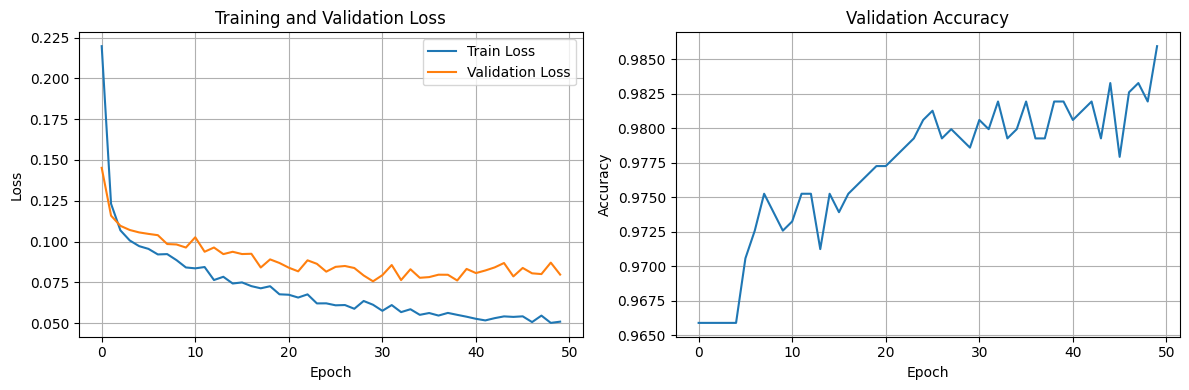

Plots saved to ../results/training_history.png


In [9]:
# Cell 9: Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(val_accuracies)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.savefig('../results/training_history.png')
plt.show()

print("Plots saved to ../results/training_history.png")

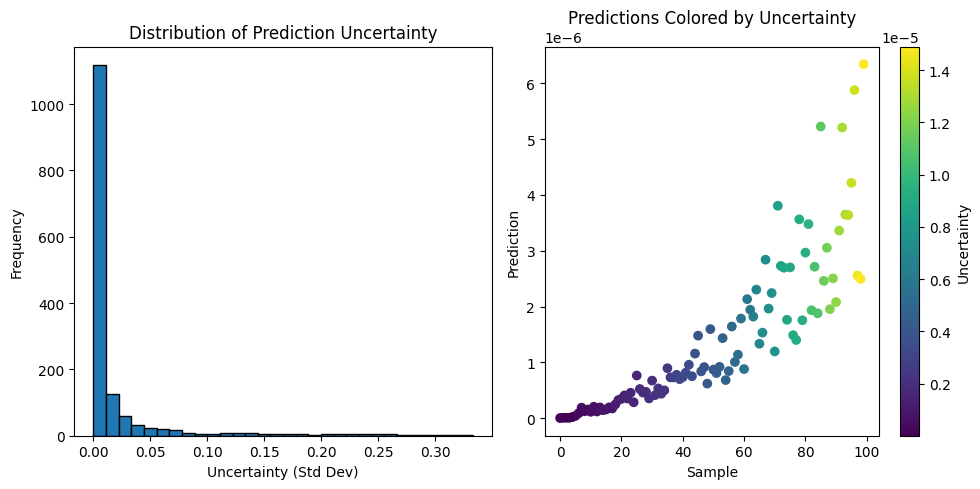

Uncertainty analysis saved to ../results/uncertainty_analysis.png


In [10]:
# Cell 10: Uncertainty visualization
# Get predictions for test set
test_mean_preds = []
test_std_preds = []

model.to(device)
for i in range(0, len(X_test), 100):
    batch = X_test_tensor[i:i+100].to(device)
    means, stds = predict_with_uncertainty(model, batch, n_samples=50)
    test_mean_preds.extend(means.flatten())
    test_std_preds.extend(stds.flatten())

# Plot uncertainty distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(test_std_preds, bins=30, edgecolor='black')
plt.xlabel('Uncertainty (Std Dev)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Uncertainty')

plt.subplot(1, 2, 2)
# Sort by uncertainty and plot
sorted_indices = np.argsort(test_std_preds)[:100]
plt.scatter(range(100), np.array(test_mean_preds)[sorted_indices], 
           c=np.array(test_std_preds)[sorted_indices], cmap='viridis')
plt.colorbar(label='Uncertainty')
plt.xlabel('Sample')
plt.ylabel('Prediction')
plt.title('Predictions Colored by Uncertainty')

plt.tight_layout()
plt.savefig('../results/uncertainty_analysis.png')
plt.show()

print("Uncertainty analysis saved to ../results/uncertainty_analysis.png")